___

# ZNE - Zero Noise Extrapolation

Essa técnica de correção de erros consiste em estimar o valor ideal sem erro para um valor estimado baseado em um parâmetro λ que é responsável por quantizar o erro de um circuito quântico. Para implementar o ZNE é então necessário encontrar um método rigoroso e reprodutível para aumentar o erro de um circuito quântico de maneira padronizada e logo determinar o valor esperado para cada nível de erro λ, E(λ). Sendo assim, podemos implementar o ZNE seguindo esses 2 passos: 

1. **Noise-Scaling** : Medir E(λ) para *m* distintos valores de λ ≥ 1.

2. **Extrapolation** : Inferir E(λ = 0) utilizando os *m* valores esperados determinados no passo anterior.

___

## Noise Scaling Methods 

Assim como discutimos anteriormente, é necessário encontrar um método para aumentar sistematicamente o erro de um circuito quântico. Existem diversas possibilidades para fazer isso, porém aqui utilizaremos uma técnica de **gate-folding** assim como uma técnica que envolve escalar o ruido utilizando **parâmetros** de gates quânticos. 

### A. Unitary Folding

Essa técnica utiliza o seguinte fato para aumentar o tamanho de um circuito quântico:

$$U \rightarrow U(U^{\dagger}U)^n$$

Dado que $U^{\dagger}U = I$, por definição. Sendo assim, podemos utilizar essa técnica para aumentar o tamanho de um circuito quântico e, dessa forma, aumentar o erro do circuito e escalar o parâmetro λ, dado que o número de operações aumenta com um fator de $1 + 2n$. Aqui o operador $U$ pode representar tanto *gates* unitários quanto o próprio circuito quântico inteiro. 

#### 1. Circuit Folding

Seja o circuito quântico representado por: 

$$U = L_{d}...L_{2}L_{1}$$

Onde $d$ é o *depth* do *qc*, circuito quântico, e cada $L_{n}$ representa uma *layer* do circuito, que pode ser um gate ou um conjunto de gates. Quando realizamos um circuit-folding do qc completo, multiplicamos o depth por um fator de $1 + 2n$, assumindo que temos um depth original de $d$:

$$
[U] = d \quad \therefore \quad [U^\dagger U] = d + d = 2d
\\~\\
[U(U^{\dagger}U)^n] = d + n(2d) = d (1 + 2n)
$$

Sendo assim, como $1 + 2n$ é sempre um número ímpar, o fator pelo qual multiplicamos o depth do qc sempre será ímpar. Para mitigar isso, estabeleceremos a seguinte regra de folding chamada de *partial-folding*: 

$$
U \rightarrow U(U^{\dagger}U)^n L_{d}^\dagger L_{d-1}^\dagger ... L_{s}^\dagger L_{s} ... L_{d-1}L_{d} = U'

\\~\\

[U'] = d (1 + 2n) + (d - s) + (s - d) = d (1 + 2n) + 2s 
$$

Com esse novo depth de $d (1 + 2n) + 2s$ temos uma possibilidade maior de escolher o valor de λ.

λ é portanto o fato de escala do circuito, ele é definido como a razão $\lambda = \frac{d_{\text{nova}}}{d_{\text{original}}}$. Definindo $k$ como uma constante que define o total de camadas adicionadas, então: $k = (n * d) + s$. Sendo assim : 

$$

\lambda = \frac{d_{\text{nova}}}{d_{\text{original}}} = \frac{d(2n + 1) + 2s}{d} = \frac{d(2n + 1 + \frac{2s}{d})}{d} = \frac{d(2n + 1)}{d} + \frac{2s}{d} = \frac{2nd + d + 2s}{d} = \frac{2k + d}{d} = 1 + \frac{2k}{d}
$$

Sendo assim, temos uma nova relação para o $\lambda$, $\lambda = 1 + \frac{2k}{d}$, utilizando o parâmetro relacionando o $k$ ao contrário de $n$ e $s$.

Para encontrar o valor de $k$ e consequentemente o valor de $n$ e $s$, e aplicar o algoritmo, utilizamos os seguintes passos: 

1. Determinar o inteiro $k$ mais próximo do valor real $d(\lambda -1)/2$

2. Realize uma divisão inteira de $k$ por $d$. O quociente corresponde a $n$, enquanto o resto corresponde a $s$.

3. Aplique $n$ dobragens inteiras e uma dobragem parcial com $s$ final. 

___
___


<div style="background-color: #453a3aff; padding: 10px; width: 100%; border-radius: 5px;">


Para criar esse código utilizaremos a função [random_circuit](https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_random) para gerar qc aleatórios para teste

Vamos criar a própria função para gerar circuitos aleatórios que possa ser customizada a fim de incluir apenas os gates que queremos, dado que precisamos de circuitos quânticos em que todos os seus gates admitam um inverso. Isso é trivial em princípio, dado que todos os gates quânticos são unitários e portanto reversíveis, porém, como estamos lidando com computadores quânticos que admitem apenas alguns gates, existe a possibilidade de que um computador quântico específico não possua suporte para o correspondente *dagger* do próprio gate.

</div>

In [2]:
from Requirements import *

In [3]:
def qc_generator(num_qubits, depth, clifford = False, gates = None, measure = None, distribution = 0.7) :

    """
    Gera um circuito quântico aleatório utilizando gates de 1 ou 2 qubits apenas.
        
    Parâmetros:
        num_qubits (int): número de qubits
        depth (int): profundidade
        clifford (bool): se True, usa apenas portas Clifford
        gates (list) : Conjunto de gates para utilizar -> [["1 qubit gates"], ["2 qubit gates"]]
        measure (bool) : Medir ao final.
        distribution (float) : De 0 até 1 e determina a probabilidade de escolher um gate de 1 qubit vs 2
    
    Retorna: QuantumCircuit
    
    Todo: Incluir 3+ qubit gates. 
    """

    if gates == None:

        if clifford:
            one_qubit_gates = ['h', 's', 'x', 'y', 'z']
            two_qubit_gates = ['cx']
            
        else:
            one_qubit_gates = ['h', 's', 'x', 'y', 'z', 't', 'rx', 'ry', 'rz']
            two_qubit_gates = ['cx', 'cz']
            
    else : 
        
        one_qubit_gates, two_qubit_gates = gates[0], gates[1]
        
    qc = QuantumCircuit(num_qubits)
    
    for a in range(depth):
        
        if random.random() < distribution:
            
            gate_choice = one_qubit_gates[random.randint(0, len(one_qubit_gates) - 1)]
            
            qubit_choice = random.randint(0, num_qubits - 1)
            
            if gate_choice in (gates_config := ['rx', 'ry', 'rz']):
                
                angle_choice = random.uniform(0, 2*pi)
                
                getattr(qc, gate_choice)(angle_choice, qubit_choice)
            
            else : 
                
                getattr(qc, gate_choice)(qubit_choice)
                
        else : 
            
            gate_choice = two_qubit_gates[random.randint(0, len(two_qubit_gates) - 1)]
            
            qubit_1, qubit_2  = random.sample(range(num_qubits), 2)
            
            getattr(qc, gate_choice)(qubit_1, qubit_2)
    
    if measure : 
        
        qc.measure_all()
        
    return qc

7


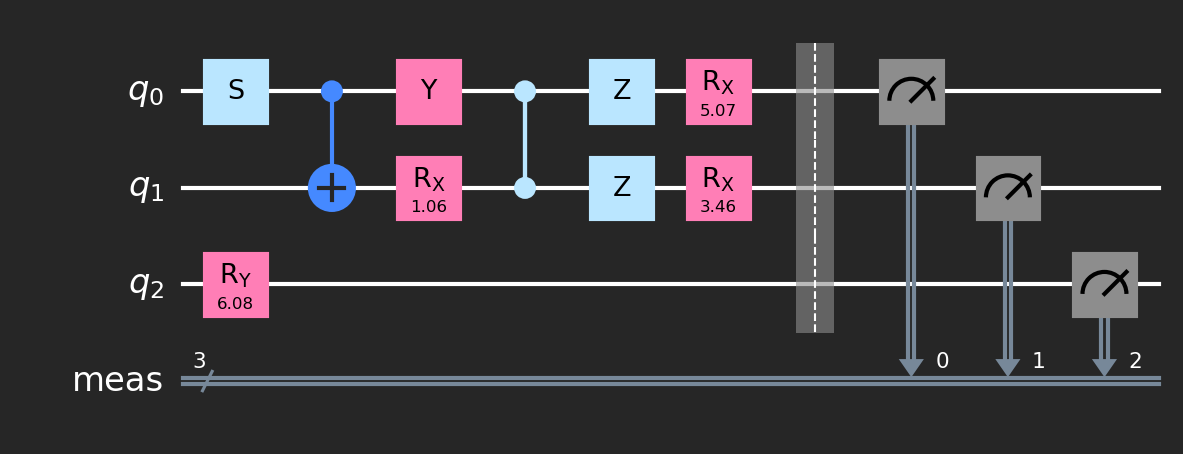

In [4]:
qc = qc_generator(num_qubits = 3, depth = 10, measure = True)

print(qc.depth())

qc.draw()

11


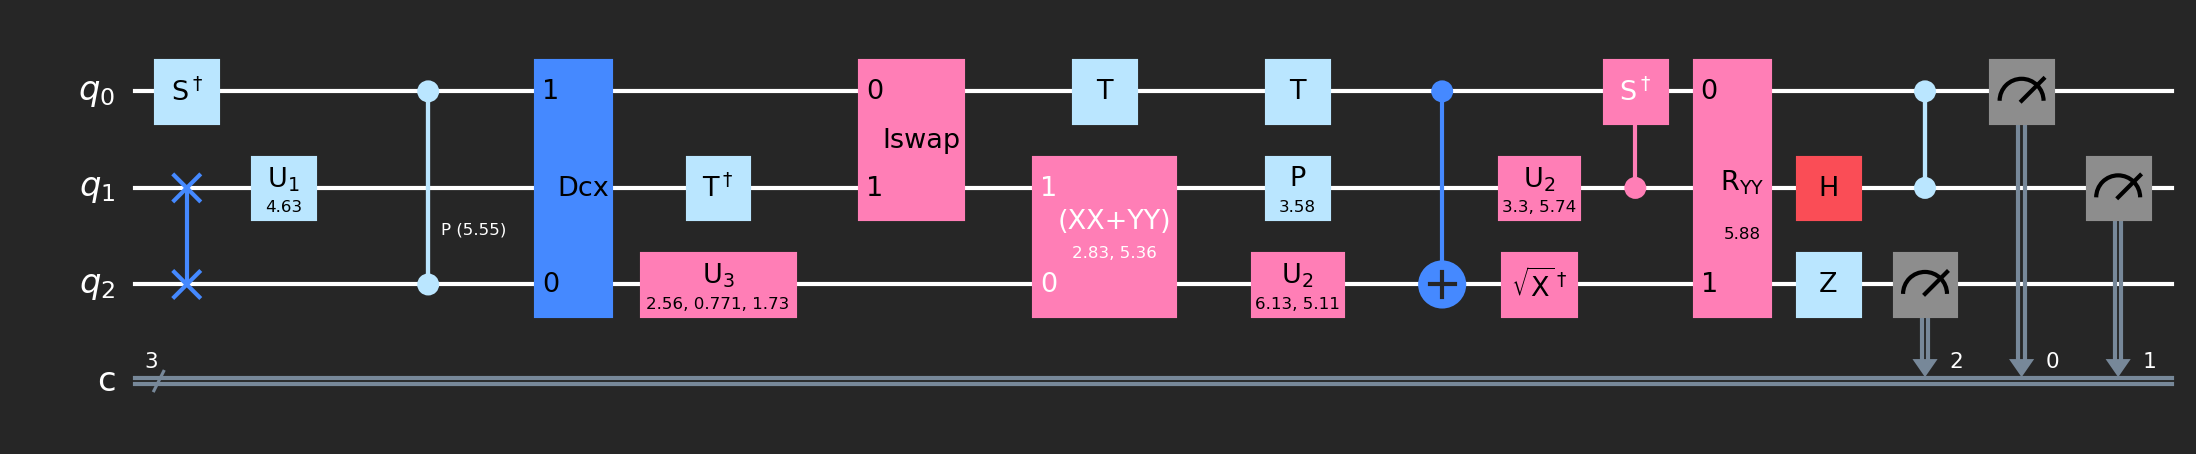

In [5]:
qc = random_circuit(num_qubits = 3, depth = 10, measure = True)

print(qc.depth())

qc.draw()

A função `qc_generator` ja consegue criar o próprio circuito quântico, mas não está com a contagem correta de depth. 

In [6]:
def qc_generator_2(num_qubits, depth, clifford = False, gates = None, measure = None, gate_density = 0.8, one_qubit_distribution = 0.7) :

    """
    Gera um circuito quântico aleatório utilizando gates de 1 ou 2 qubits apenas.
        
    Parâmetros:
        num_qubits (int): número de qubits
        depth (int): profundidade
        clifford (bool): se True, usa apenas portas Clifford
        gates (list) : Conjunto de gates para utilizar -> [["1 qubit gates"], ["2 qubit gates"]]
        measure (bool) : Medir ao final.
        gate_density (float): Probabilidade (0 a 1) de adicionar um gate em um qubit disponível em cada camada. Densidade de gates do circuito.
        one_qubit_distribution (float): Probabilidade (0 a 1) de o gate a ser adicionado ser de 1 qubit (vs. 2 qubits).
    
    Retorna: QuantumCircuit
    
    Todo: Incluir 3+ qubit gates. 
    """

    if gates == None:

        if clifford:
            one_qubit_gates = [HGate, SGate, XGate, YGate, ZGate]
            two_qubit_gates = [CXGate]
            
        else:
            one_qubit_gates = [HGate, SGate, XGate, YGate, ZGate, TGate, RXGate, RYGate, RZGate]
            two_qubit_gates = [CXGate, CZGate]
            
    else : 
        
        one_qubit_gates, two_qubit_gates = gates[0], gates[1]
        
    qc = QuantumCircuit(num_qubits)
    
    principal_register = random.randint(0, num_qubits - 1)
    
    for a in range(depth):
        
        gate_class = random.choice(one_qubit_gates)
        
        if gate_class in [RXGate, RYGate, RZGate]:
            
            angle = random.uniform(0, 2 * pi)
            qc.append(gate_class(angle), [principal_register])
            
        else:
            
            qc.append(gate_class(), [principal_register])
    
    gate_total = int(num_qubits * depth * gate_density)
    
    max_try = gate_total * 5
    try_ = 0

    while qc.size() < gate_total and try_ < max_try:
        try_ += 1
        
        if random.random() < one_qubit_distribution:
            
            gate_class = random.choice(one_qubit_gates)
            qubit_alvo = random.randint(0, num_qubits - 1)
            
            if gate_class in [RXGate, RYGate, RZGate]:
                
                angle = random.uniform(0, 2 * pi)
                qc.append(gate_class(angle), [qubit_alvo])
                
            else:
                
                qc.append(gate_class(), [qubit_alvo])
        
        else:
        
            if num_qubits < 2: 
                
                continue 
        
            gate_class = random.choice(two_qubit_gates)
            
            q1, q2 = random.sample(range(num_qubits), 2)
            
            qc.append(gate_class(), [q1, q2])

        if qc.depth() > depth:

            qc.data.pop()

    if measure:
        
        qc.measure_all()
        
    return qc



11


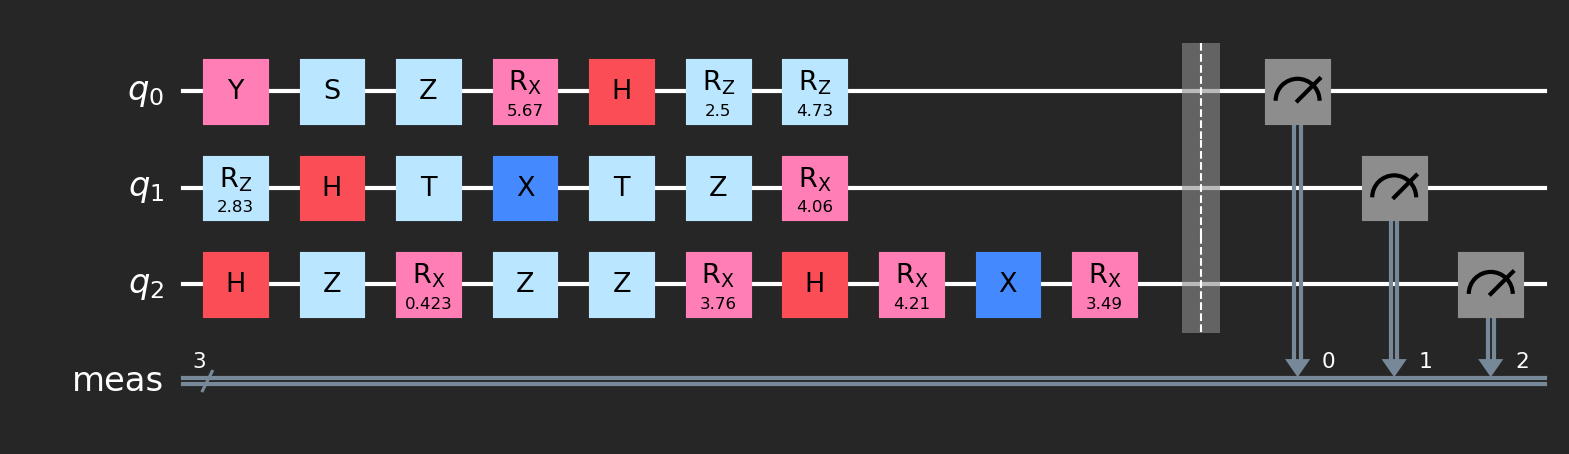

In [7]:
qc = qc_generator_2(num_qubits = 3, depth = 10, measure = True)

print(qc.depth())

qc.draw()

11


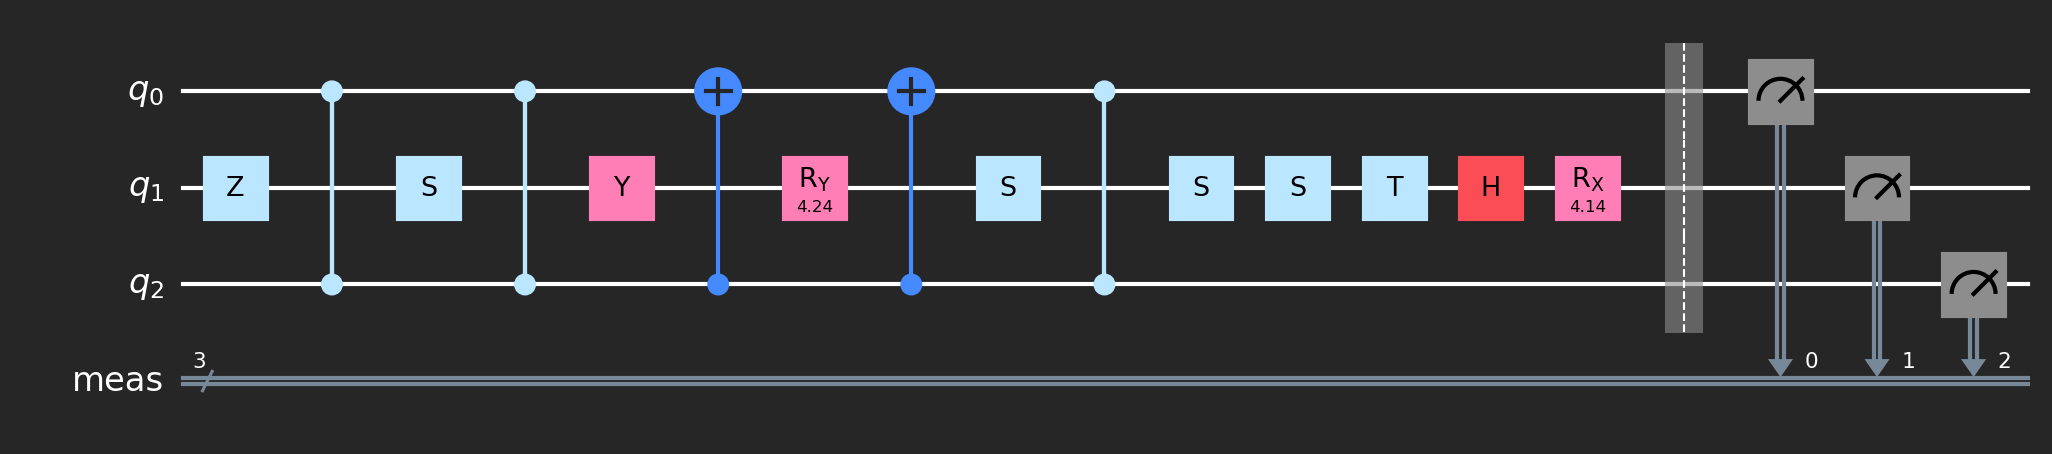

In [8]:
qc = qc_generator_2(num_qubits = 3, depth = 10, gate_density = 0.5, one_qubit_distribution = 0.1, measure = True)

print(qc.depth())

qc.draw()

In [9]:
def qc_generator_3(num_qubits, depth, clifford = False, gates = None, measure = None, gate_density = 0.8, one_qubit_distribution = 0.7) :

    """
    Gera um circuito quântico aleatório utilizando gates de 1 ou 2 qubits apenas.
        
    Parâmetros:
        num_qubits (int): número de qubits
        depth (int): profundidade
        clifford (bool): se True, usa apenas portas Clifford
        gates (list) : Conjunto de gates para utilizar -> [["1 qubit gates"], ["2 qubit gates"]]
        measure (bool) : Medir ao final.
        gate_density (float): Probabilidade (0 a 1) de adicionar um gate em um qubit disponível em cada camada. Densidade de gates do circuito.
        one_qubit_distribution (float): Probabilidade (0 a 1) de o gate a ser adicionado ser de 1 qubit (vs. 2 qubits).
    
    Retorna: QuantumCircuit
    
    Todo: Incluir 3+ qubit gates. 
    """
    if depth == 0:
    
        return QuantumCircuit(num_qubits)
    
    if gates is None:
        
        if clifford:
            
            one_qubit_gates = ['h', 's', 'x', 'y', 'z']
            two_qubit_gates = ['cx']
        
        else:
        
            one_qubit_gates = ['h', 's', 'x', 'y', 'z', 't', 'rx', 'ry', 'rz']
            two_qubit_gates = ['cx', 'cz']
    
    else:
    
        one_qubit_gates, two_qubit_gates = gates[0], gates[1]
        
    qc = QuantumCircuit(num_qubits)
    
    while qc.depth() < depth:
    
        if random.random() < one_qubit_distribution or num_qubits < 2:
    
            gate_choice = random.choice(one_qubit_gates)
            qubit_alvo = random.randint(0, num_qubits - 1)
            
            if gate_choice in ['rx', 'ry', 'rz']:
    
                angle = random.uniform(0, 2 * pi)
                getattr(qc, gate_choice)(angle, qubit_alvo)
            
            else:
            
                getattr(qc, gate_choice)(qubit_alvo)
        
        else:
        
            gate_choice = random.choice(two_qubit_gates)
            q1, q2 = random.sample(range(num_qubits), 2)
            getattr(qc, gate_choice)(q1, q2)

    total_gates = int(num_qubits * depth * gate_density)
    
    while qc.size() < depth:
        gate_choice = random.choice(one_qubit_gates)
        qubit_alvo = random.randint(0, num_qubits - 1)
        getattr(qc, gate_choice)(qubit_alvo)
    
    if qc.size() >= total_gates:
        if measure:
            qc.measure_all()
        return qc

    max_try = (total_gates - qc.size()) * 10 
    try_ = 0
    
    while qc.size() < total_gates and try_ < max_try:
    
        try_ += 1
        
        if random.random() < one_qubit_distribution or num_qubits < 2:
            
            gate_choice = random.choice(one_qubit_gates)
            qubit_alvo = random.randint(0, num_qubits - 1)
            
            if gate_choice in ['rx', 'ry', 'rz']:
            
                getattr(qc, gate_choice)(random.uniform(0, 2 * pi), qubit_alvo)
            
            else:
            
                getattr(qc, gate_choice)(qubit_alvo)
        
        else:
        
            gate_choice = random.choice(two_qubit_gates)
            q1, q2 = random.sample(range(num_qubits), 2)
            getattr(qc, gate_choice)(q1, q2)

        if qc.depth() > depth:
        
            qc.data.pop()

    if measure:
        
        qc.measure_all()
        
    return qc

11


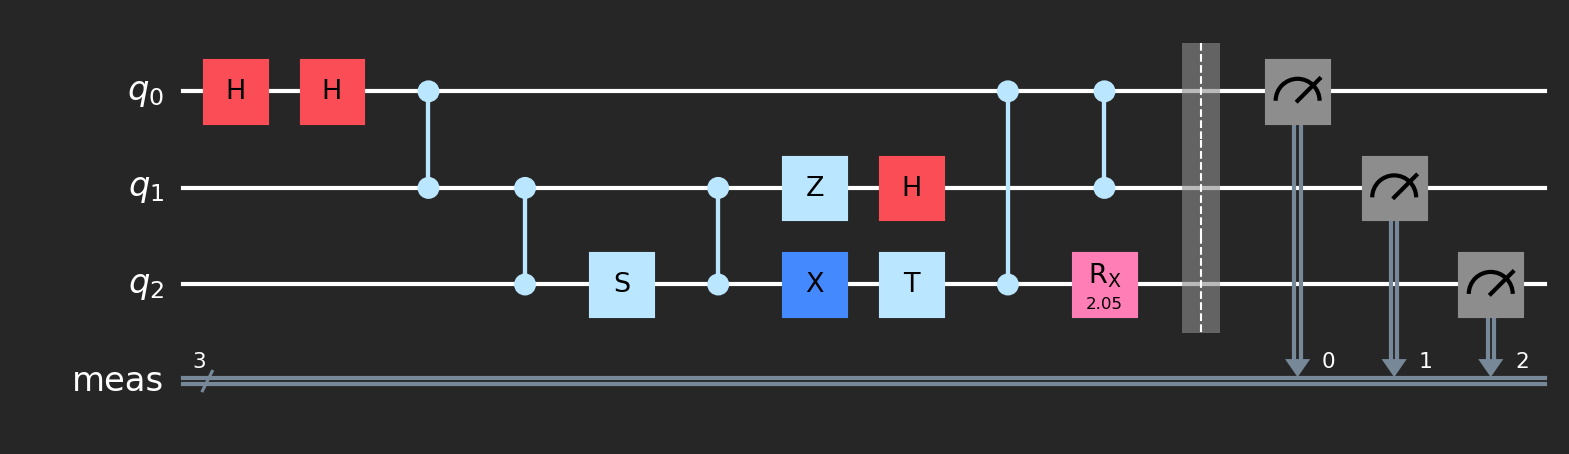

In [10]:
qc = qc_generator_3(num_qubits = 3, depth = 10, gate_density = 0.7, measure = True)

print(qc.depth())

qc.draw()

In [11]:
def qc_generator_4(num_qubits, depth, clifford=False, gates=None, measure=False, gate_density=0.5, one_qubit_distribution=0.7):

    if depth == 0 or num_qubits == 0:
        
        return QuantumCircuit(num_qubits)

    gate_density = max(0, min(1, gate_density))

    if gates is None:
        
        if clifford:
            
            one_qubit_gates = ['h', 's', 'x', 'y', 'z']
            two_qubit_gates = ['cx']
        
        else:
        
            one_qubit_gates = ['h', 's', 'x', 'y', 'z', 't', 'rx', 'ry', 'rz']
            two_qubit_gates = ['cx', 'cz']
    
    else:
        one_qubit_gates, two_qubit_gates = gates[0], gates[1]

    matriz_circuito = [[None for _ in range(num_qubits)] for _ in range(depth)]
    
    principal_register = random.randint(0, num_qubits - 1)
    
    for i in range(depth):
    
        gate = random.choice(one_qubit_gates)
        params = (random.uniform(0, 2*pi),) if gate in ['rx', 'ry', 'rz'] else ()
        matriz_circuito[i][principal_register] = (gate, params)

    for i in range(depth):
    
        for j in range(num_qubits):
    
            if j == principal_register: 
                continue
    
            if random.random() < gate_density:
                
                gate = random.choice(one_qubit_gates)
                params = (random.uniform(0, 2*pi),) if gate in ['rx', 'ry', 'rz'] else ()
                matriz_circuito[i][j] = (gate, params)

    num_total_slots = num_qubits * depth
    num_mutacoes_alvo = int(num_total_slots * gate_density * (1 - one_qubit_distribution))
    
    if num_qubits > 1:

        for _ in range(num_mutacoes_alvo):

            camada_idx = random.randint(0, depth - 1)
            
            try:
                q1, q2 = random.sample(range(num_qubits), 2)
                
            except ValueError:
                continue 
            
            gate_info1 = matriz_circuito[camada_idx][q1]
            gate_info2 = matriz_circuito[camada_idx][q2]
            
            if (gate_info1 and gate_info1[0] in one_qubit_gates and
                gate_info2 and gate_info2[0] in one_qubit_gates):
                
                gate_2q = random.choice(two_qubit_gates)
                control, target = sorted([q1, q2]) 
                
                gate_representacao = (gate_2q, (control, target))
                
                matriz_circuito[camada_idx][control] = gate_representacao
                matriz_circuito[camada_idx][target] = gate_representacao

    qc = QuantumCircuit(num_qubits)

    for i in range(depth):

        gates_na_camada = set()

        for j in range(num_qubits):

            gate_info = matriz_circuito[i][j]

            if gate_info is None or id(gate_info) in gates_na_camada:
                continue
            
            gate, params = gate_info
            gates_na_camada.add(id(gate_info))

            if gate in two_qubit_gates:
                
                control, target = params
                getattr(qc, gate)(control, target)
            
            else:
                if params:
                    getattr(qc, gate)(*params, j)
            
                else:
                    getattr(qc, gate)(j)

    if measure:
        qc.measure_all()
        
    return qc

11


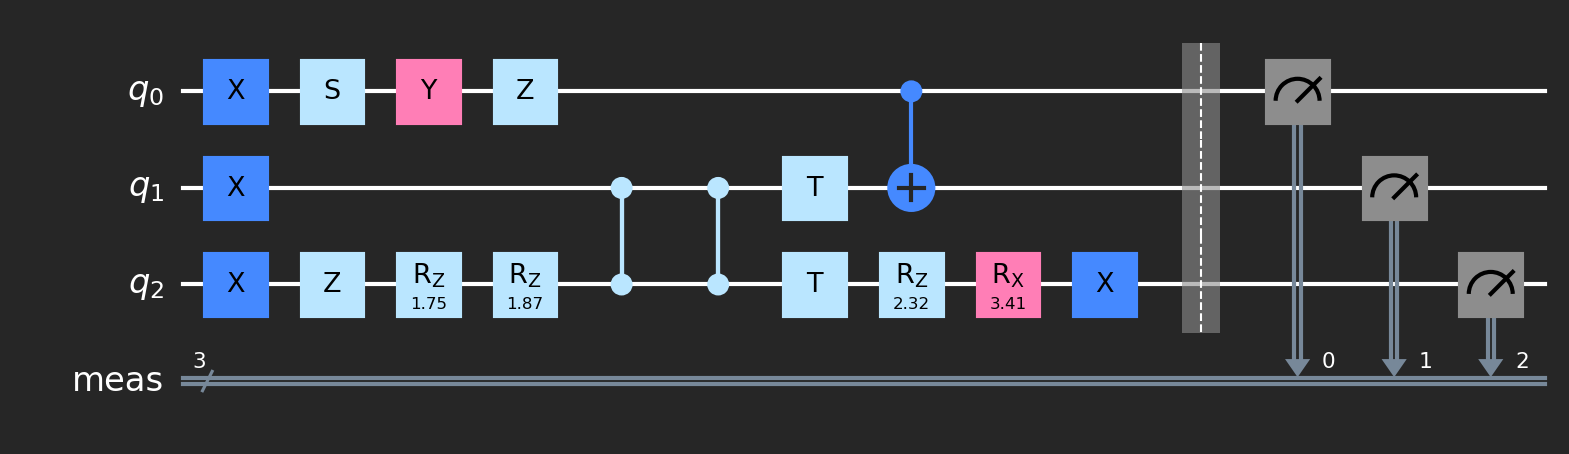

In [12]:
qc = qc_generator_4(num_qubits = 3, depth = 10, gate_density = 0.5, one_qubit_distribution= 0.7, measure = True)

print(qc.depth())

qc.draw()

In [13]:
def qc_generator_final(num_qubits, depth, clifford=False, gates=None, measure=False, gate_density=0.5, one_qubit_distribution=0.7):
    
    """
    Gera um circuito quântico aleatório com registro principal garantido.
    
    Args:
        num_qubits: Número de qubits
        depth: Profundidade do circuito (número de camadas)
        clifford: Se True, usa apenas gates Clifford
        gates: Tupla (gates_1q, gates_2q) ou None para usar padrão
        measure: Se True, adiciona medição no final
        gate_density: Densidade de gates nos registros secundários (0.0 a 1.0)
                      0 = apenas registro principal preenchido
                      1 = circuito inteiro preenchido
        one_qubit_distribution: Fração de gates que devem ser de 1 qubit (0.0 a 1.0)
    
    Returns:
        QuantumCircuit: Circuito quântico gerado
    """
    
    if depth == 0 or num_qubits == 0:
        return QuantumCircuit(num_qubits)
    
    gate_density = max(0.0, min(1.0, gate_density))
    one_qubit_distribution = max(0.0, min(1.0, one_qubit_distribution))

    if gates is None:
        
        if clifford:
            
            one_qubit_gates = ['h', 's', 'x', 'y', 'z']
            two_qubit_gates = ['cx']
        
        else:
            
            one_qubit_gates = ['h', 's', 'x', 'y', 'z', 't', 'rx', 'ry', 'rz']
            two_qubit_gates = ['cx', 'cz']
        
    else:
        one_qubit_gates, two_qubit_gates = gates[0], gates[1]
    
    circuit_matrix = [[None for _ in range(num_qubits)] for _ in range(depth)]
    main_register = random.randint(0, num_qubits - 1)
    
    def place_1q_gate(gate_name, params, layer, qubit):
        
        circuit_matrix[layer][qubit] = ('1q', gate_name, params, qubit)
    
    def place_2q_gate(gate_name, layer, qubit1, qubit2):
        
        gate_id = random.random()
        gate_info = ('2q', gate_name, (), qubit1, qubit2, gate_id)
        circuit_matrix[layer][qubit1] = gate_info
        circuit_matrix[layer][qubit2] = gate_info
    
    def can_place_2q_gate(layer, qubit1, qubit2):
        
        return (circuit_matrix[layer][qubit1] is None and 
                circuit_matrix[layer][qubit2] is None)
    
    total_main_positions = depth
    num_1q_main = int(total_main_positions * one_qubit_distribution)
    num_2q_main = total_main_positions - num_1q_main
    
    if num_qubits == 1 or not two_qubit_gates:
        
        num_2q_main = 0
        num_1q_main = depth
    
    layer_assignments = ['1q'] * num_1q_main + ['2q'] * num_2q_main
    layer_assignments += ['1q'] * (depth - len(layer_assignments))
    layer_assignments = layer_assignments[:depth]
    random.shuffle(layer_assignments)
    
    for layer, gate_type in enumerate(layer_assignments):
        if gate_type == '1q' or num_qubits == 1:
            gate_1q = random.choice(one_qubit_gates)
            params = ()
            if gate_1q in ['rx', 'ry', 'rz']:
                params = (random.uniform(0, 2*pi),)
            
            place_1q_gate(gate_1q, params, layer, main_register)
        
        elif gate_type == '2q':
            
            other_qubits = [q for q in range(num_qubits) if q != main_register]
            target_qubit = random.choice(other_qubits)
            
            if can_place_2q_gate(layer, main_register, target_qubit):
            
                gate_2q = random.choice(two_qubit_gates)
                place_2q_gate(gate_2q, layer, main_register, target_qubit)
            
            else:
            
                gate_1q = random.choice(one_qubit_gates)
                params = ()
            
                if gate_1q in ['rx', 'ry', 'rz']:
                    params = (random.uniform(0, 2*pi),)
                
                place_1q_gate(gate_1q, params, layer, main_register)
            
    
    if gate_density > 0 and num_qubits > 1:
        
        secondary_positions = []
        
        for layer in range(depth):
        
            for qubit in range(num_qubits):
        
                if circuit_matrix[layer][qubit] is None:
                    secondary_positions.append((layer, qubit))
                
        
        positions_to_fill_count = int(len(secondary_positions) * gate_density)
        random.shuffle(secondary_positions)
        selected_positions = secondary_positions[:positions_to_fill_count]
        
        positions_by_layer = {}
        
        for layer, qubit in selected_positions:
            
            if layer not in positions_by_layer:
                positions_by_layer[layer] = []
            
            positions_by_layer[layer].append(qubit)
        
        total_secondary_gates = positions_to_fill_count
        num_1q_secondary = int(total_secondary_gates * one_qubit_distribution)
        num_2q_secondary = (total_secondary_gates - num_1q_secondary) // 2
        
        gates_1q_placed = 0
        gates_2q_placed = 0
        
        for layer, qubits in positions_by_layer.items():
            
            if gates_2q_placed >= num_2q_secondary:
                break
            
            available_in_layer = [q for q in qubits if circuit_matrix[layer][q] is None]
            
            while len(available_in_layer) >= 2 and gates_2q_placed < num_2q_secondary:
                
                q1 = available_in_layer.pop(random.randint(0, len(available_in_layer)-1))
                q2 = available_in_layer.pop(random.randint(0, len(available_in_layer)-1))
                
                if can_place_2q_gate(layer, q1, q2):
                    
                    gate_2q = random.choice(two_qubit_gates)
                    place_2q_gate(gate_2q, layer, q1, q2)
                    gates_2q_placed += 1
        
        for layer, qubit in selected_positions:
        
            if circuit_matrix[layer][qubit] is None and gates_1q_placed < num_1q_secondary:
        
                gate_1q = random.choice(one_qubit_gates)
                params = ()
        
                if gate_1q in ['rx', 'ry', 'rz']:
                    params = (random.uniform(0, 2*pi),)
                
                place_1q_gate(gate_1q, params, layer, qubit)
                gates_1q_placed += 1
    
    qc = QuantumCircuit(num_qubits)
    processed_gate_ids = set()
    
    for layer_index in range(depth):
        
        for qubit_index in range(num_qubits):
            
            gate_info = circuit_matrix[layer_index][qubit_index]
            
            if gate_info is None:
                continue
            
            gate_type = gate_info[0]
            
            if gate_type == '1q':
                
                _, gate_name, params, target_qubit = gate_info
                
                if params:
                    getattr(qc, gate_name)(*params, target_qubit)
                
                else:
                    getattr(qc, gate_name)(target_qubit)
                
            
            elif gate_type == '2q':
                _, gate_name, params, qubit1, qubit2, gate_id = gate_info
                
                if gate_id not in processed_gate_ids:
                    processed_gate_ids.add(gate_id)
                    
                    if gate_name == 'cx':
                        if random.random() < 0.5:
                            control, target = qubit1, qubit2
                        
                        else:
                            control, target = qubit2, qubit1
                        
                        qc.cx(control, target)
                    
                    elif gate_name == 'cz':
                        qc.cz(qubit1, qubit2)
                    
                    else:
                        getattr(qc, gate_name)(qubit1, qubit2)
                    
    if measure:
        qc.measure_all()
    
    return qc

11


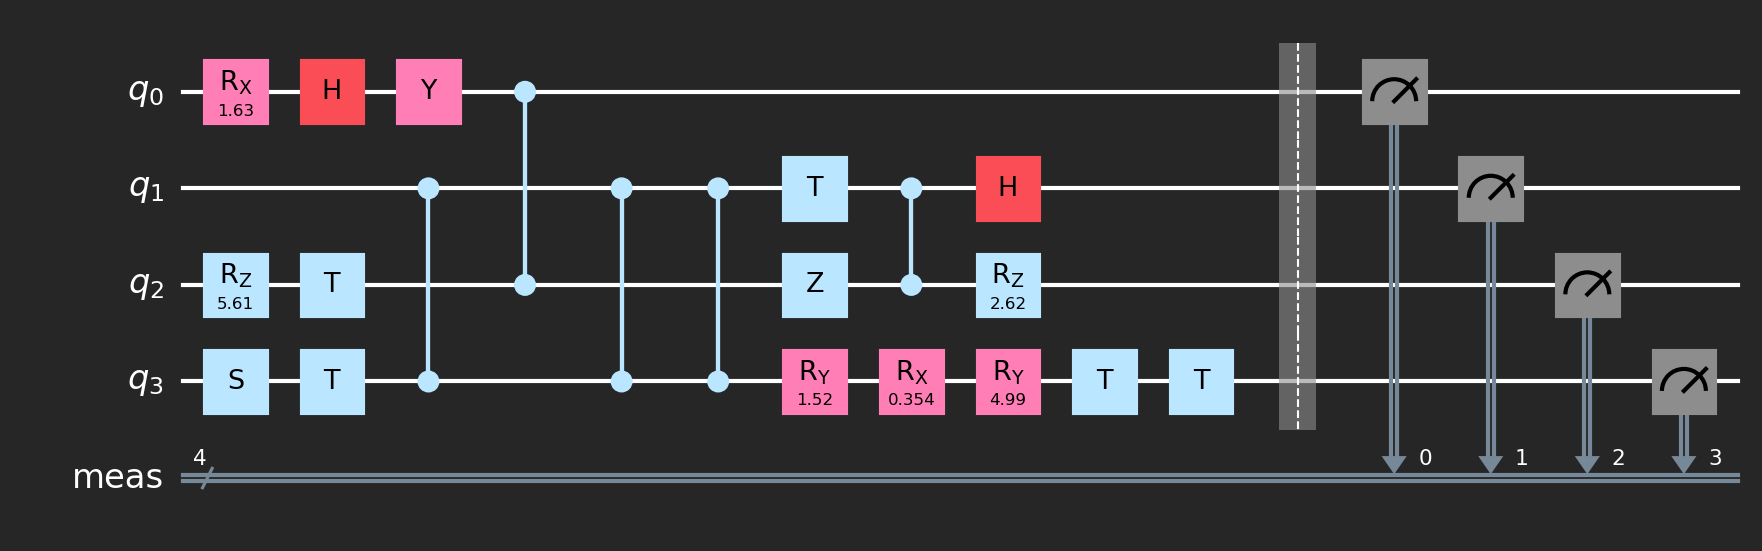

In [14]:
qc = qc_generator_final(num_qubits=4, depth=10, gate_density=0.5, one_qubit_distribution=0.7, measure = True)

print(qc.depth())

qc.draw()


‎ 

<div style="background-color: #453a3aff; padding: 10px; width: 100%; border-radius: 5px;">


Com a nossa função `qc_generator_final` podemos finalmente criar um circuito quântico com um `depth` específico. O próximo passo é desenvolver a função de Circuit Folding. Para isso, vamos separar em 2 funções, `total_circuit_folding` e  `partial_circuit_folding`, logo juntar em uma única função, `circuit_folding` que dado um circuito quântico `qc` e um valor de $\lambda$ produz um circuito quântico com a escala desejada. 

</div>

‎ 


10


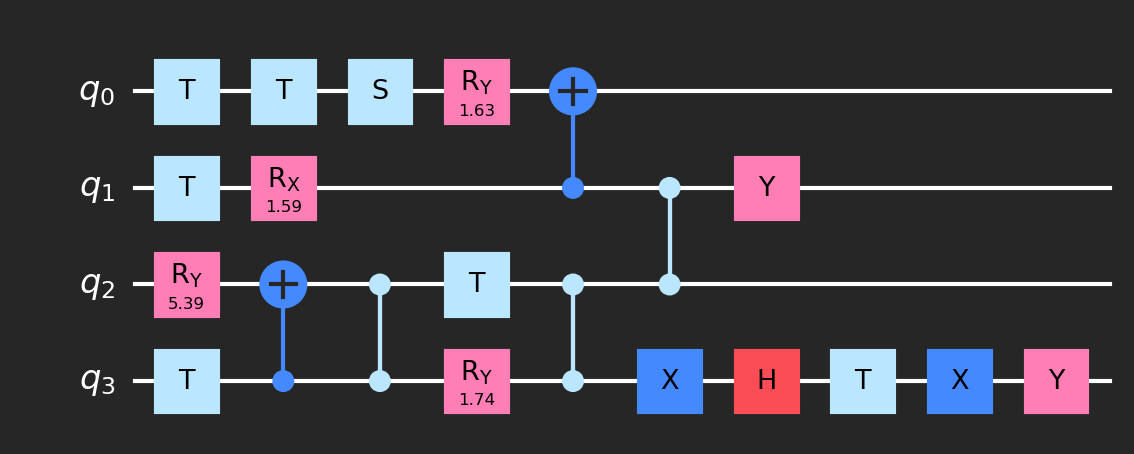

In [15]:
qc = qc_generator_final(num_qubits=4, depth=10, gate_density=0.5, one_qubit_distribution=0.7, measure = False)

print(qc.depth())

qc.draw()

10


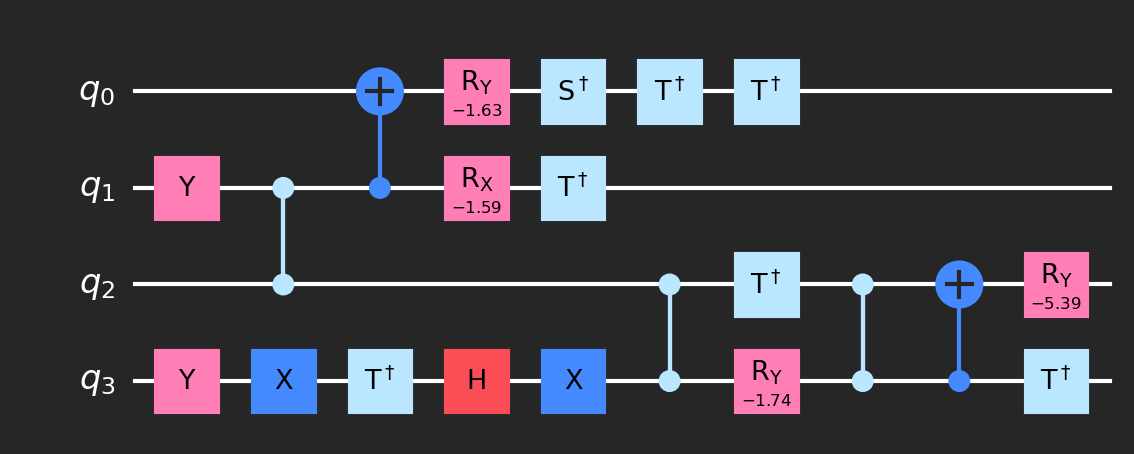

In [16]:
qc_inverse = qc.inverse()

print(qc_inverse.depth())

qc_inverse.draw()

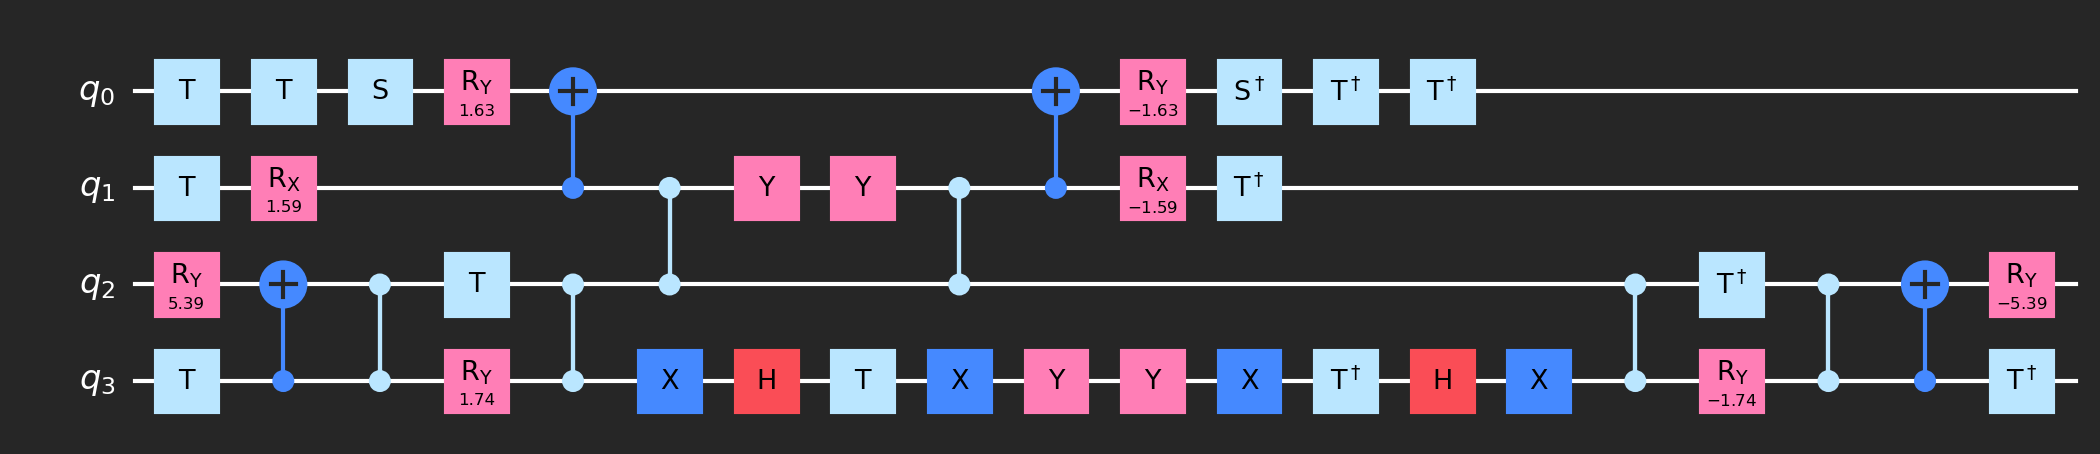

In [17]:
qc_total = qc.compose(qc_inverse)

qc_total.draw()

In [18]:
qc_total_ = qc_total.copy()

num_qubits = qc_total_.num_qubits

unitary_simulator = AerSimulator(method='unitary')

qc_total_.save_unitary()

result = unitary_simulator.run(qc_total_).result()

unitary_matrix = result.get_unitary(qc_total_)

#print(unitary_matrix)

identity_matrix = np.eye(2**num_qubits)

are_matrices_equal = np.allclose(unitary_matrix, identity_matrix)

print(are_matrices_equal)

True


In [19]:
qc_total.measure_all()

shots_simulator = AerSimulator()

result = shots_simulator.run(qc_total, shots=1024).result()

counts = result.get_counts()

#plot_distribution(counts, color = ['#66b3ff'])

print(counts)

{'0000': 1024}


In [20]:
def total_circuit_folding(quantum_circuit, n = 1):
    
    qc = quantum_circuit.copy()
    
    qc_inverse = quantum_circuit.inverse()
    
    for _ in range(n):
    
        qc = qc.compose(qc_inverse.compose(quantum_circuit))
    
    return qc

10


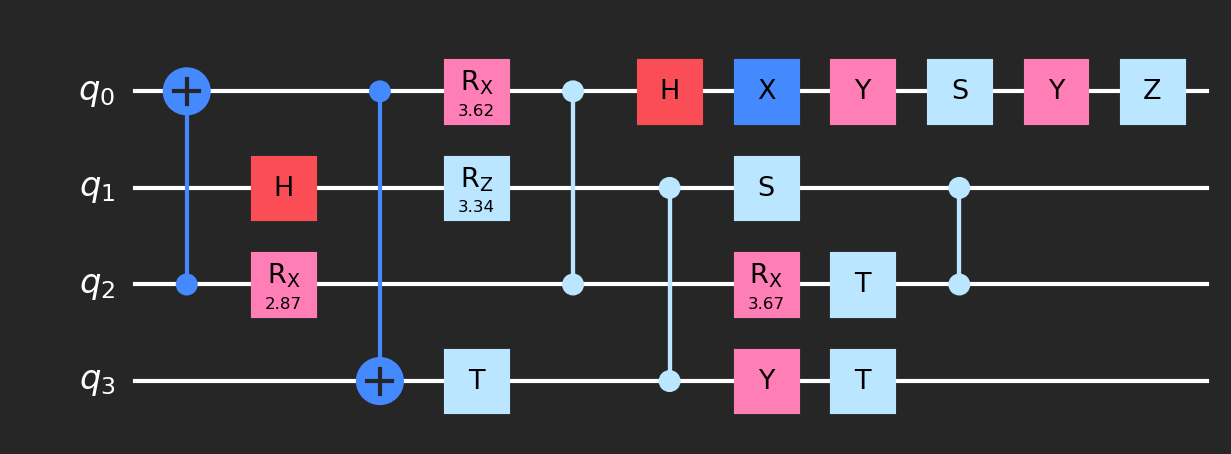

In [21]:
qc = qc_generator_final(num_qubits=4, depth=10, gate_density=0.5, one_qubit_distribution=0.7, measure = False)

print(qc.depth())

qc.draw()

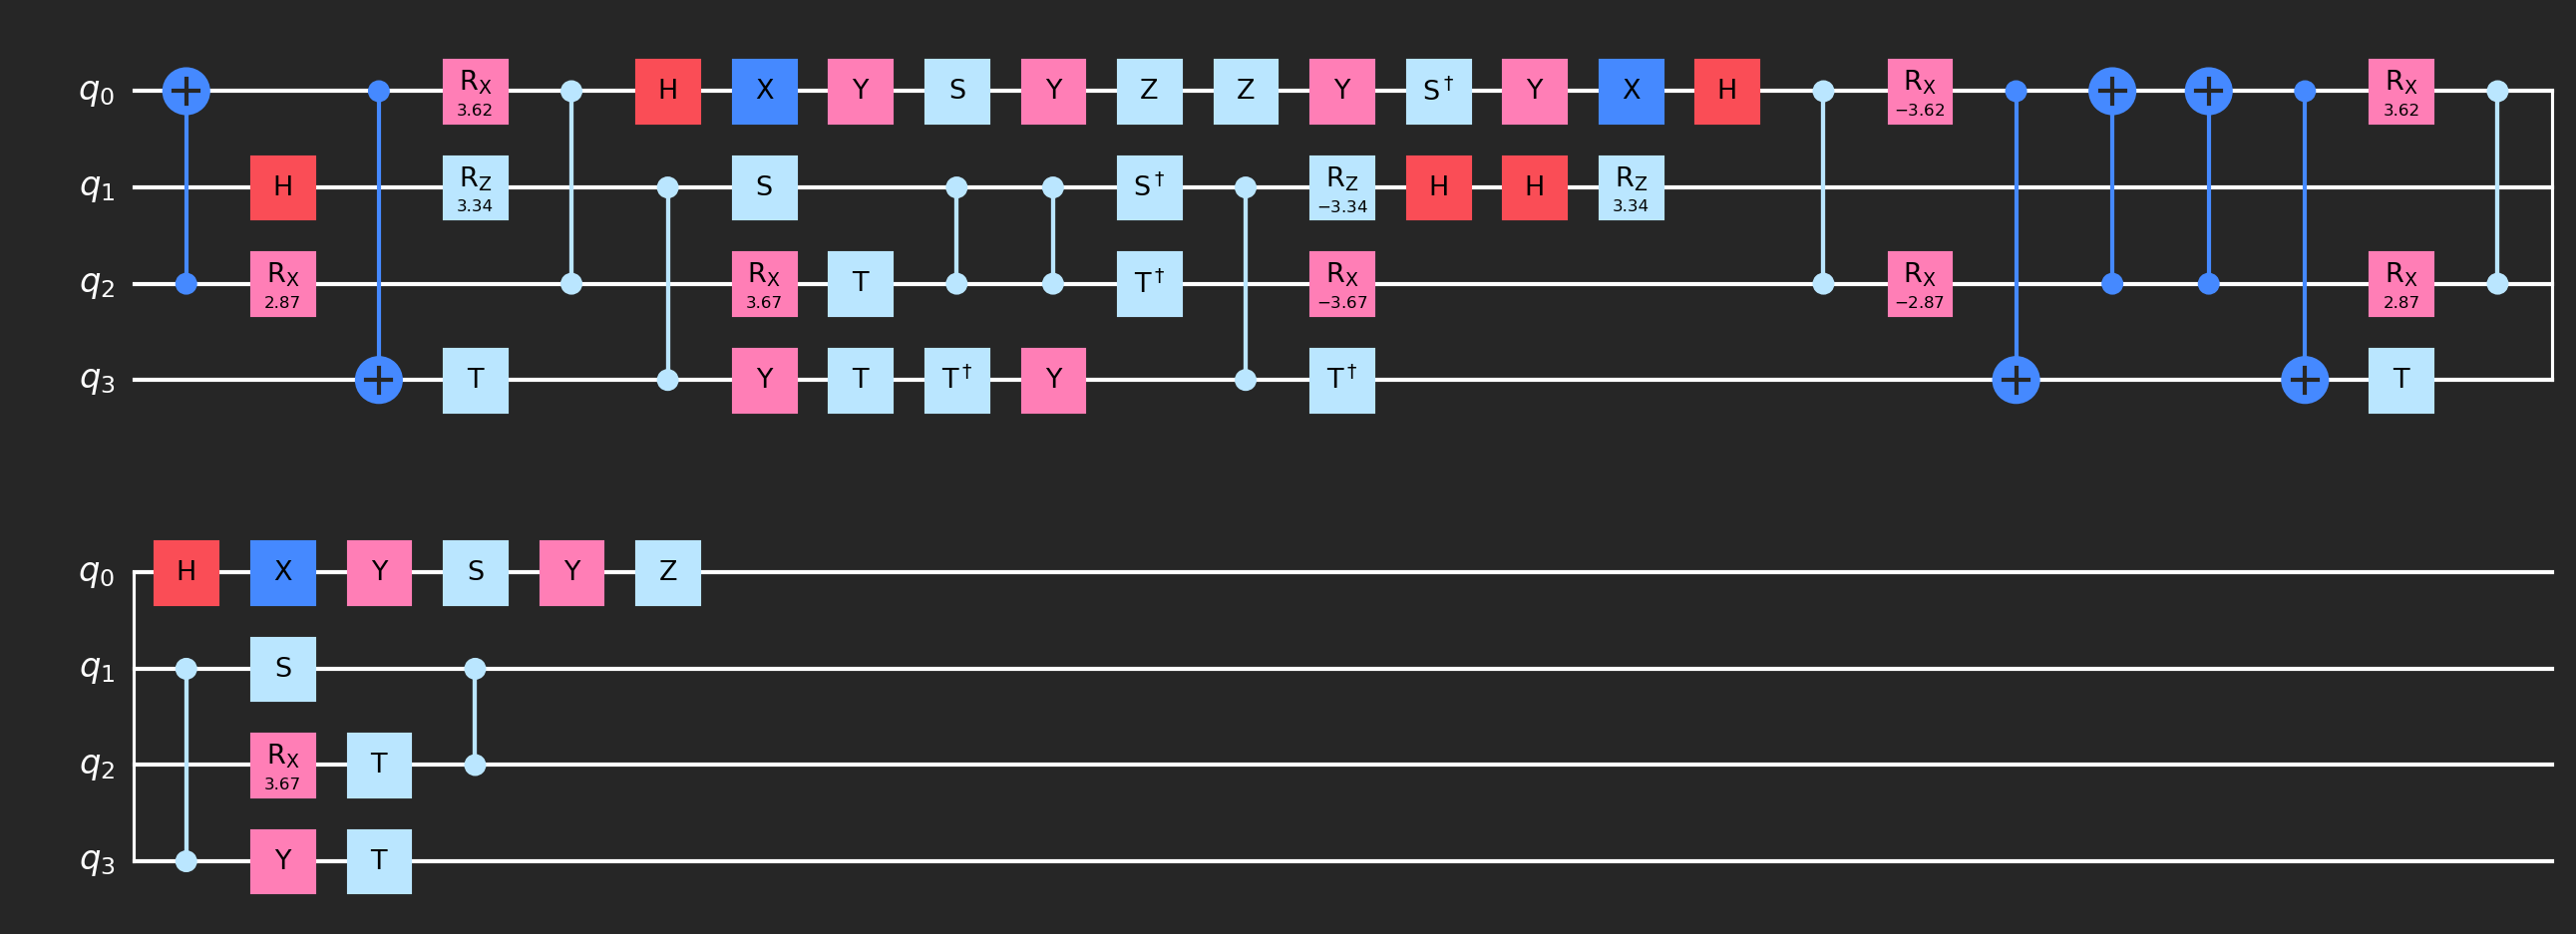

In [22]:
total_circuit_folding(qc).draw()


‎ 

<div style="background-color: #453a3aff; padding: 10px; width: 100%; border-radius: 5px;">


Com a função `total_circuit_folding` podemos utilizar o $n$ para determinar o número de vezes que realizaremos um folding total do circuito. Com isso, a seguir vamos determinar uma maneira de testar os circuitos quânticos a fim de garantir que depois que são duplicados eles continuam equivalentes. 

</div>

‎ 


In [23]:
def test_qc(qc1, qc2):
    
    if qc1.num_clbits > 0:
        
        qc1.remove_final_measurements(inplace=True)
    
    if qc2.num_clbits > 0:
        
        qc2.remove_final_measurements(inplace=True)
        
    op1 = Operator(qc1)
    
    op2 = Operator(qc2)
    
    return op1.equiv(op2)


In [24]:
qc = qc_generator_final(num_qubits=4, depth=10, gate_density=0.5, one_qubit_distribution=0.7, measure = False)
qc_inverse = total_circuit_folding(qc)

print(test_qc(qc, qc_inverse))

True



‎ 

<div style="background-color: #453a3aff; padding: 10px; width: 100%; border-radius: 5px;">


Com a função `test_qc` podemos comparar 2 circuitos para verificar se são equivalentes. O último problema agora é implementar a função `partial_circuit_folding`. Para isso é necessário determinar uma maneira de extrair os últimos $s$ 'layers' do circuito. Aqui, **a palavra 'layers' pode significar gates de 1 ou de todos os registros**. 

Digamos que sejam os últimos $s$ gates de todos os registros simultaneamente. Isso inclui a ordem de execução? Ou seja, pego os últimos $s$ gates independentemente de quando serão executados ou devo seguir essa ordem de execução. 

De qualquer maneira, não podemos utilizar a propriedade `qc.data[:]` dado que essa propriedade apenas nos mostra as últimas instruções para montar o qc e não necessariamente a ordem global nem de execução. 

</div>

‎ 


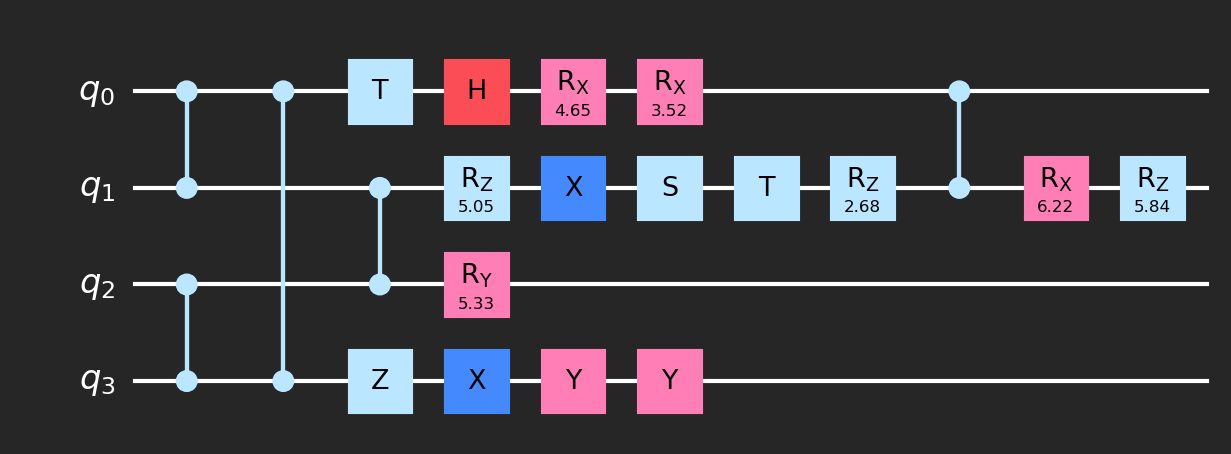

In [25]:
qc.draw()

In [26]:
qc.data[-5:]

[CircuitInstruction(operation=Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 1), Qubit(QuantumRegister(4, 'q'), 0)), clbits=()),
 CircuitInstruction(operation=Instruction(name='rx', num_qubits=1, num_clbits=0, params=[6.221267449963893]), qubits=(Qubit(QuantumRegister(4, 'q'), 1),), clbits=()),
 CircuitInstruction(operation=Instruction(name='y', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 3),), clbits=()),
 CircuitInstruction(operation=Instruction(name='rz', num_qubits=1, num_clbits=0, params=[5.84400188071069]), qubits=(Qubit(QuantumRegister(4, 'q'), 1),), clbits=()),
 CircuitInstruction(operation=Instruction(name='ry', num_qubits=1, num_clbits=0, params=[5.329339119412869]), qubits=(Qubit(QuantumRegister(4, 'q'), 2),), clbits=())]

In [27]:
dag = circuit_to_dag(qc)

layers = list(dag.layers())

for i, layer in enumerate(layers):
    
    print(f"Layer {i}: {[node.op.name for node in layer['graph'].op_nodes()]}")

Layer 0: ['cz', 'cz']
Layer 1: ['cz', 'cz']
Layer 2: ['t', 'rz', 'z', 'ry']
Layer 3: ['h', 'x', 'x']
Layer 4: ['rx', 's', 'y']
Layer 5: ['rx', 't', 'y']
Layer 6: ['rz']
Layer 7: ['cz']
Layer 8: ['rx']
Layer 9: ['rz']


In [28]:
def partial_circuit_folding(quantum_circuit, s, return_with_original = False):

    if s == 0:
        
        return QuantumCircuit(*quantum_circuit.qregs, *quantum_circuit.cregs) if not return_with_original else quantum_circuit.copy()

    dag = circuit_to_dag(quantum_circuit)
    
    layers = list(dag.layers())
    
    if s > len(layers):
        
        raise ValueError(f"s ({s}) > depth total do circuito ({len(layers)}).")

    last_s_layers = layers[-s:]

    sub_circuit = QuantumCircuit(*quantum_circuit.qregs, *quantum_circuit.cregs)

    for layer in last_s_layers:

        layer_dag = layer['graph']

        for node in layer_dag.op_nodes():
            sub_circuit.append(node.op, node.qargs, node.cargs)
    
    sub_circuit_inverse = sub_circuit.inverse()

    folded_qc = sub_circuit_inverse.compose(sub_circuit)

    return folded_qc if not return_with_original else quantum_circuit.copy().compose(folded_qc)

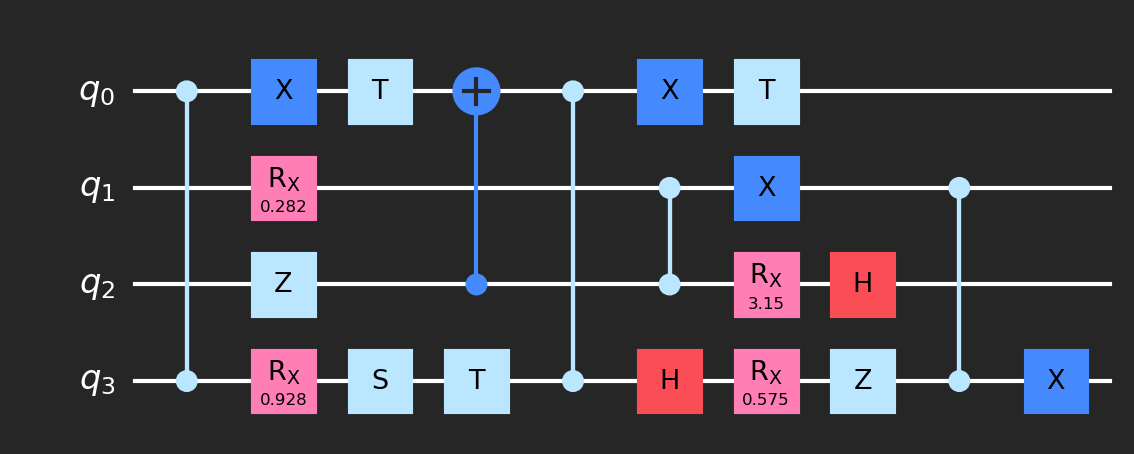

In [29]:
qc = qc_generator_final(num_qubits=4, depth=10, gate_density=0.5, one_qubit_distribution=0.7, measure = False)

qc.draw()

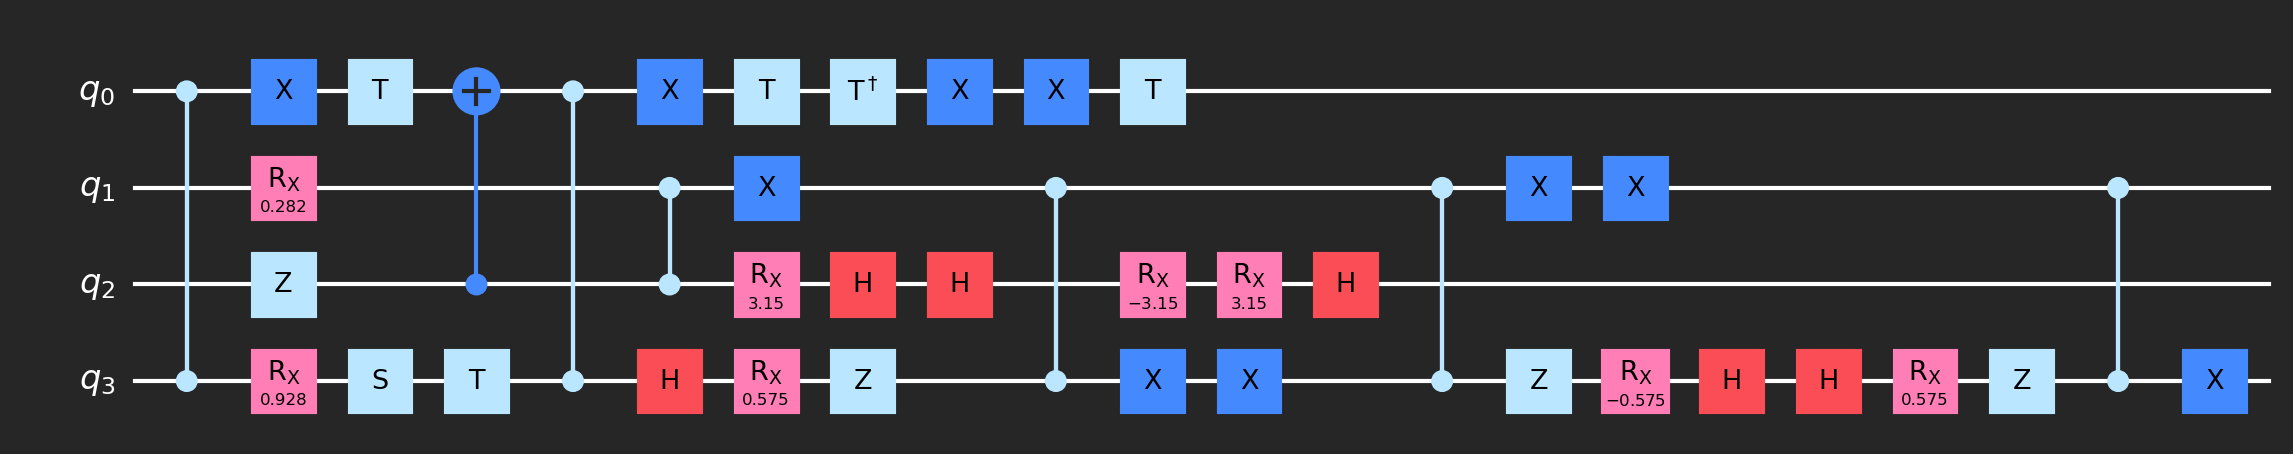

In [30]:
s = 5

qc_folded = partial_circuit_folding(qc, s, return_with_original = True)

qc_folded.draw()

In [31]:
test_qc(qc, qc_folded)

True


‎ 

<div style="background-color: #453a3aff; padding: 10px; width: 100%; border-radius: 5px;">


Com a função `partial_circuit_folding` podemos realizar o partial fold dos qc. Finalmente podemos então juntar as funções `partial_circuit_folding` e `total_circuit_folding` para gerar uma função `circuit_folding` que, dado o valor de $\lambda$, encontra o valor de $k$ e com isso determina apropriadamente os valores de $n$ e $s$ para utilizar nas funções de ajuda.

Para isso, devemos encontrar $k$ a partir de $d$. Assim como na função `partial_circuit_folding`, substituímos o valor de $d$ definido por depth, `.depth()`, por um valor com base em layers, definido pela implementação do `dag`. 

</div>

‎ 


In [32]:
def circuit_folding(quantum_circuit, λ, dag_vs_depth = True, verbose = False):
    
    # Por default utilizamos layers (via dag) e não depth (via depth())
    
    qc = quantum_circuit.copy()
    
    d = len(list(circuit_to_dag(qc).layers())) if dag_vs_depth == True else qc.depth()
    
    k = round((d * (λ - 1))/2)
    
    n, s = k // d, k % d
    
    if verbose: print(f"\n-------- Chosen λ : {λ} --------\nd : {d}\tReal λ : {1 + (2*k/d):.2f}\tk : {k}\nn : {n}\ts : {s}\n")
    
    return total_circuit_folding(qc, n = n).compose(partial_circuit_folding(qc, s = s))

Depth : 10	Layers : 10


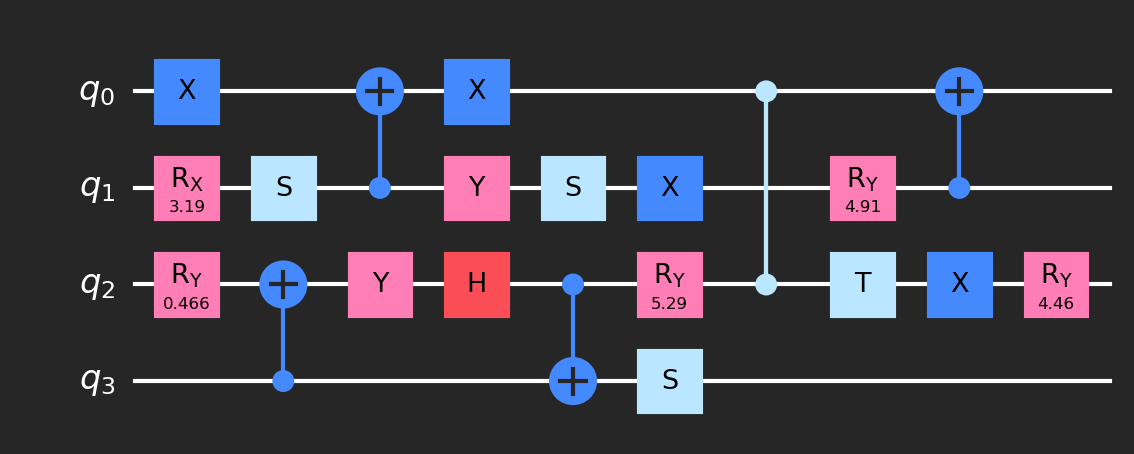

In [33]:
qc = qc_generator_final(num_qubits=4, depth=10, gate_density=0.5, one_qubit_distribution=0.7, measure = False)

print(f"Depth : {qc.depth()}\tLayers : {len(list(circuit_to_dag(qc).layers()))}")

qc.draw()

In [34]:
qc_folded_1 = circuit_folding(qc, 1, verbose = True)

print(f"Is equivalent : {test_qc(qc, qc_folded_1)}")

qc_folded_2 = circuit_folding(qc, 2, verbose = True)

print(f"Is equivalent : {test_qc(qc, qc_folded_2)}")

qc_folded_3 = circuit_folding(qc, 3, verbose = True)

print(f"Is equivalent : {test_qc(qc, qc_folded_3)}")


-------- Chosen λ : 1 --------
d : 10	Real λ : 1.00	k : 0
n : 0	s : 0

Is equivalent : True

-------- Chosen λ : 2 --------
d : 10	Real λ : 2.00	k : 5
n : 0	s : 5

Is equivalent : True

-------- Chosen λ : 3 --------
d : 10	Real λ : 3.00	k : 10
n : 1	s : 0

Is equivalent : True


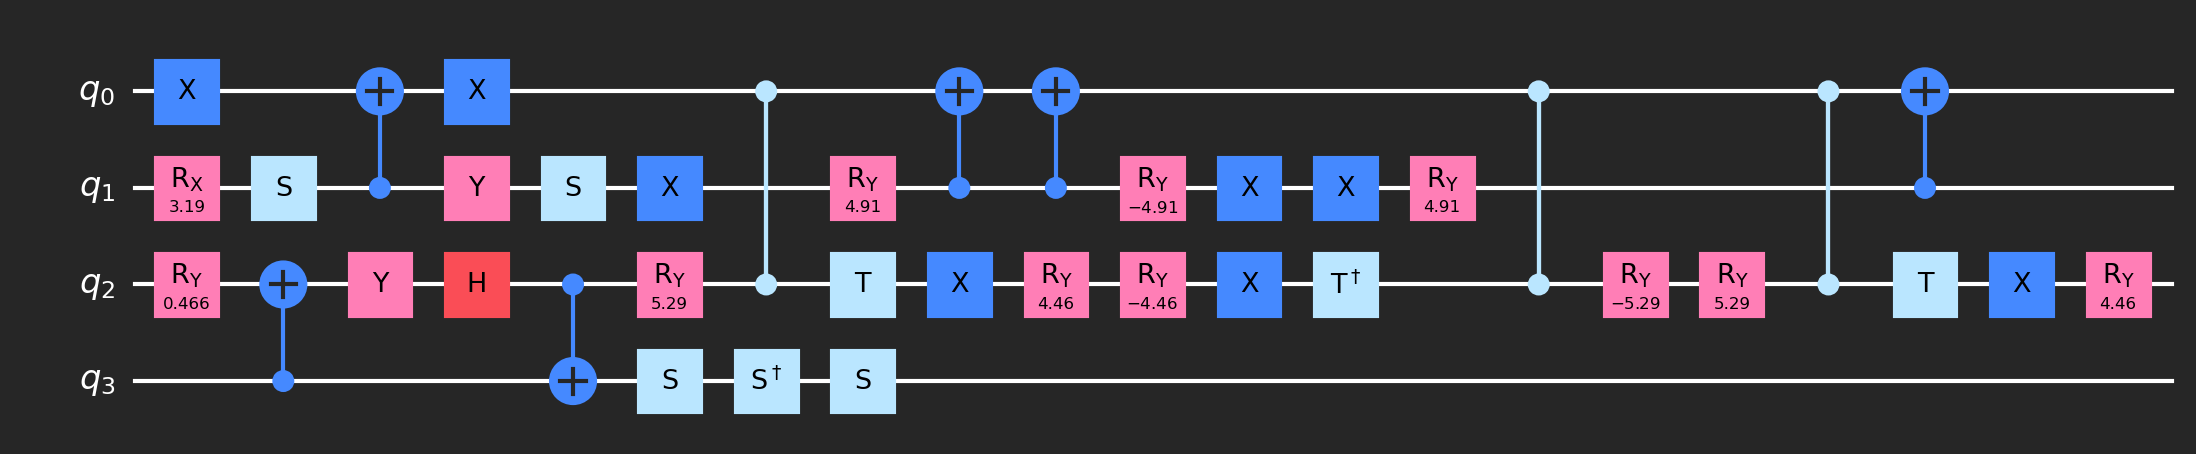

In [35]:
qc_folded_2.draw()

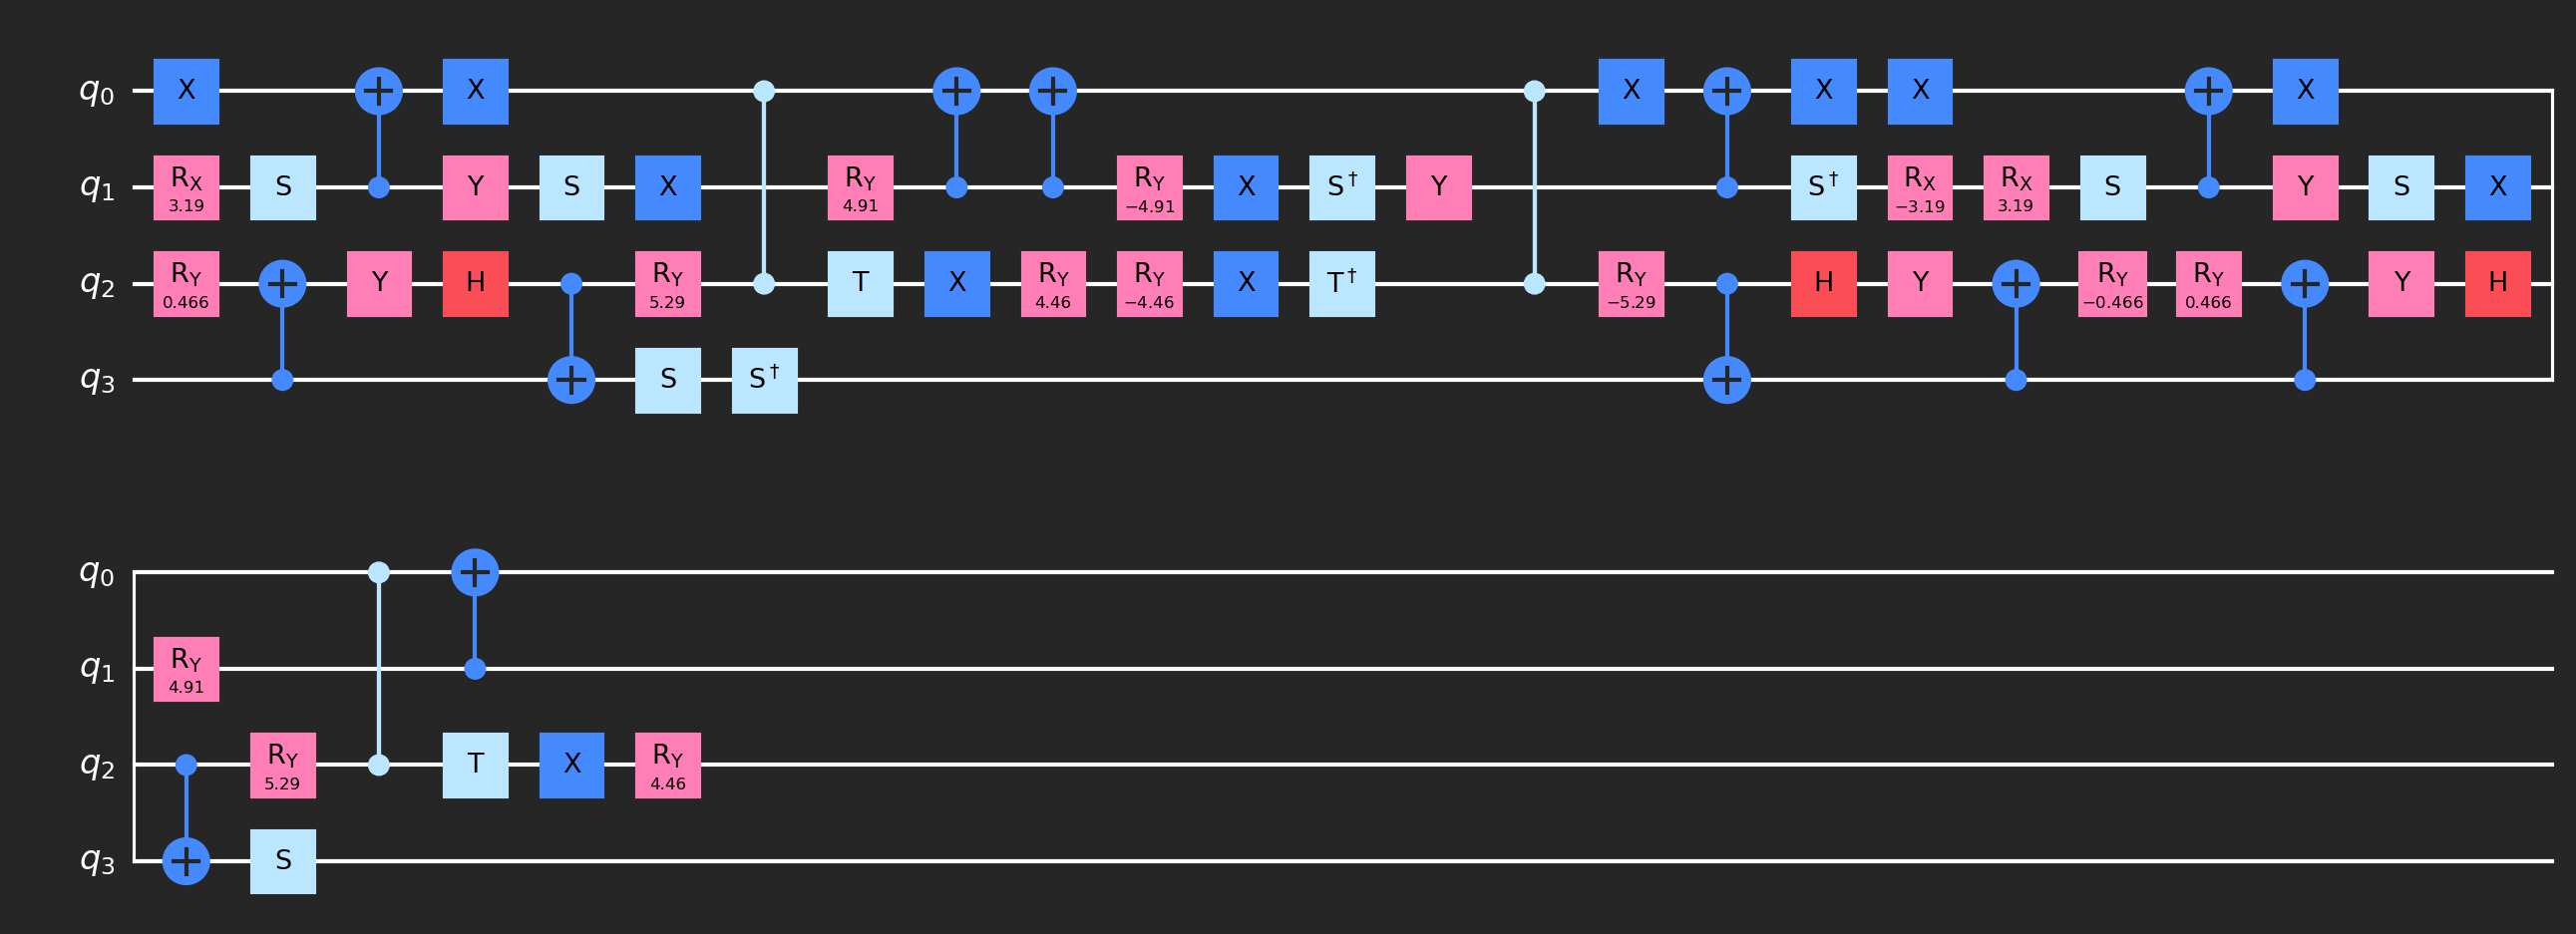

In [36]:
qc_folded_3.draw()


‎ 

____
____


#### 2. Gate Folding


O gate folding é uma técnica parecida com o Circuit Folding, porem que oferece mais precisão sobre quais gates serão dobrados. Enquanto o Circuit Folding mantém o qc original e ao final apenas realizar um append com o folding, o Gate Folding tem como objetivo realizar o folding no mesmo lugar em que o encontra. 

Digamos que nosso circuito quântico depth de $d$ :

$$U = L_{d}...L_{2}L_{1}$$

Suponha que cada $L_j$ represente um gate ou um conjunto de gates em múltiplos registros. Então podemos aplicar a transformação $U \rightarrow U(U^{\dagger}U)^n$, que chamaremos de total folding.

Com isso, assim como no caso passado, se aplicarmos essa transformação para cada $L_j$, com $j \in \{0, 1, ..., d\}$, então a quantidade de layers do qc será multiplicada por um fator impar de $1 + 2n$, assim como no caso passado. 

Sendo assim, da mesma maneira que anteriormente, podemos adicionar granularidade ao realizar um partial folding para poder obter um fator de multiplicação da quantidade de layers que possa não ser impar. 

**A maneira como esse partial folding funciona no gate folding é fundamentalmente distinta de como funciona com o circuit folding**. No circuit folding o partial folding ocorria com um subset dos últimos $s$ layers do circuito quântico, logo, para completar o folding, a seguinte transformação ocorria: 

‎ 

$$
U \rightarrow U(U^{\dagger}U)^n L_{d}^\dagger L_{d-1}^\dagger ... L_{s}^\dagger L_{s} ... L_{d-1}L_{d} = U' $$

‎ 

Para o gate folding, a partial folding é distinta. Para isso, o $s$ muda, ele já não representa mais as últimas layers de um qc, agora $s$ é definido a partir de uma outra variável $S$. $S$ é um subconjunto do conjunto de indices $\{1, 2, 3, ..., d\}$, tal que o numero de elementos nesse subconjunto é justamente $s$, assim $s = |S|$. 

A partir disso **definimos o gate folding** (onde assim como o circuit folding utilizaremos $n$ e $s$): 

‎ 

$$
\forall j \in \{1, 2, 3, ..., d\}, \qquad L_j \quad \longrightarrow \quad 
\begin{cases} 
L_j(L_j^\dagger L_j)^n & \text{se }j \notin S, \\ \\
L_j(L_j^\dagger L_j)^{n+1} & \text{se }j \in S
\end{cases}
$$

‎ 

Essa formula geral para o gate folding inclui tanto o total folding quanto o partial folding. O total folding é imediatamente evidente, dado que todos os $L_j$ passam pela transformação $L_j \rightarrow L_j(L_j^\dagger L_j)^n$, e o partial folding se encontra no fato de que um total de $s$ $L_j$ passam pela transformação $L_j \rightarrow L_j(L_j^\dagger L_j)^{n+1}$, ou seja, recebem uma dobra a mais um total de $s$ vezes, dado que $j \in S$ e $s = |S|$. Assim, é como se tivéssemos uma transformação total de $L_j \rightarrow L_j(L_j^\dagger L_j)^n$ e uma parcial de $L_j \rightarrow L_j(L_j^\dagger L_j)^{1}$ em um total de $s$ lugares, ele é um contador: ele diz quantos gates recebem a dobra extra.

Dependendo de como $S$ é escolhido, teremos distintas alterações no erro amplificado, portanto, utilizaremos as seguintes opções: 

‎ 

| Method      | Subset of indices to fold                                                              |
|-------------|----------------------------------------------------------------------------------------|
| From left   | $S = \{1, 2, \dots, s\}$                                                               |
| From right  | $S = \{d, d-1, \dots, d - s + 1\}$                                                     |
| At random   | $S = s$ different indices randomly sampled without replacement from $\{1, 2, \dots, d\}$. |

‎ 

Além disso, a partir dessa formula geral do gate folding, é possível determinar que o numero de gates após o procedimento é de $d (1 + 2n) + 2s$, exatamente o mesmo para o circuit folding. Portanto, o fator de escala, $d \rightarrow \lambda d$ é exatamente o mesmo para o caso anterior, $\lambda = 1 + \frac{2k}{d}$, que significa que para encontrar os valores de $k$ e consequentemente de $n$ e de $s$ podemos utilizar os mesmos procedimentos que para o caso do circuit folding. 

‎ 


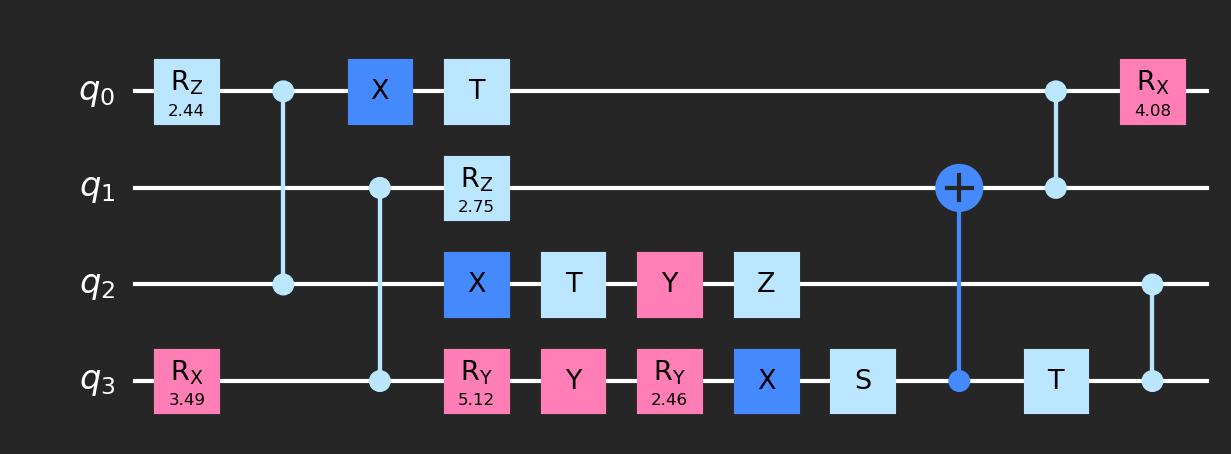

In [37]:
qc = qc_generator_final(num_qubits=4, depth=10, gate_density=0.5, one_qubit_distribution=0.7, measure = False)

qc.draw()

In [38]:
dag = circuit_to_dag(qc)

layers_list  = list(dag.layers())

print(layers_list)

[{'graph': <qiskit.dagcircuit.dagcircuit.DAGCircuit object at 0x7dfd3d10b980>, 'partition': [(Qubit(QuantumRegister(4, 'q'), 0),), (Qubit(QuantumRegister(4, 'q'), 3),)]}, {'graph': <qiskit.dagcircuit.dagcircuit.DAGCircuit object at 0x7dfd3d108f50>, 'partition': [(Qubit(QuantumRegister(4, 'q'), 2), Qubit(QuantumRegister(4, 'q'), 0)), (Qubit(QuantumRegister(4, 'q'), 3), Qubit(QuantumRegister(4, 'q'), 1))]}, {'graph': <qiskit.dagcircuit.dagcircuit.DAGCircuit object at 0x7dfd3da3ae10>, 'partition': [(Qubit(QuantumRegister(4, 'q'), 2),), (Qubit(QuantumRegister(4, 'q'), 3),), (Qubit(QuantumRegister(4, 'q'), 0),), (Qubit(QuantumRegister(4, 'q'), 1),)]}, {'graph': <qiskit.dagcircuit.dagcircuit.DAGCircuit object at 0x7dfd36303a40>, 'partition': [(Qubit(QuantumRegister(4, 'q'), 3),), (Qubit(QuantumRegister(4, 'q'), 2),), (Qubit(QuantumRegister(4, 'q'), 0),)]}, {'graph': <qiskit.dagcircuit.dagcircuit.DAGCircuit object at 0x7dfd35f1b830>, 'partition': [(Qubit(QuantumRegister(4, 'q'), 3),), (Qubit(

In [39]:
for i, layer in enumerate(layers_list):
    
    layer_dag = layer['graph']
    
    layer_circuit = dag_to_circuit(layer_dag)
    
    print(f"\n--- Camada {i} ---\n")
    
    print(layer_circuit)


--- Camada 0 ---

     ┌────────────┐
q_0: ┤ Rz(2.4386) ├
     └────────────┘
q_1: ──────────────
                   
q_2: ──────────────
     ┌────────────┐
q_3: ┤ Rx(3.4918) ├
     └────────────┘

--- Camada 1 ---

           
q_0: ─■────
      │    
q_1: ─┼──■─
      │  │ 
q_2: ─■──┼─
         │ 
q_3: ────■─
           

--- Camada 2 ---

         ┌───┐     
q_0: ────┤ X ├─────
     ┌───┴───┴────┐
q_1: ┤ Rz(2.7545) ├
     └───┬───┬────┘
q_2: ────┤ X ├─────
     ┌───┴───┴────┐
q_3: ┤ Ry(5.1248) ├
     └────────────┘

--- Camada 3 ---

     ┌───┐
q_0: ┤ T ├
     └───┘
q_1: ─────
     ┌───┐
q_2: ┤ T ├
     ├───┤
q_3: ┤ Y ├
     └───┘

--- Camada 4 ---

                   
q_0: ──────────────
                   
q_1: ──────────────
         ┌───┐     
q_2: ────┤ Y ├─────
     ┌───┴───┴────┐
q_3: ┤ Ry(2.4555) ├
     └────────────┘

--- Camada 5 ---

          
q_0: ─────
          
q_1: ─────
     ┌───┐
q_2: ┤ Z ├
     ├───┤
q_3: ┤ X ├
     └───┘

--- Camada 6 ---

          
q_0: ─────

In [40]:
def gate_folding(quantum_circuit, λ, method = "left", dag_vs_depth = True, verbose = False):
    
    # method = ["left", "right", "random"]
    
    qc = quantum_circuit.copy()
    
    dag = circuit_to_dag(qc)

    layers_list  = list(dag.layers())

    d = len(list(circuit_to_dag(qc).layers())) if dag_vs_depth else qc.depth()
    
    k = round((d * (λ - 1))/2)
    
    n, s = divmod(k, d)
    
    if verbose: 
        
        print(f"\n-------- Chosen λ : {λ} --------\nd : {d}\tReal λ : {1 + (2*k/d):.2f}\tk : {k}\nn : {n}\ts : {s}\n")
    
    indices = list(range(d))
    
    S = {"left" : indices[:s], "right" : indices[-s:], "random" : random.sample(indices, s)}[method]
    
    folded_qc = QuantumCircuit(*qc.qregs, *qc.cregs)
    
    for i, layer in enumerate(layers_list):
        
        layer_circuit = dag_to_circuit(layer['graph'])
        
        layer_inverse = layer_circuit.inverse()
    
        num_folds = n + 1 if i in S else n
        
        folded_qc.compose(layer_circuit, inplace=True)
        
        fold_block = layer_inverse.compose(layer_circuit)
    
        for _ in range(num_folds):
            
            folded_qc.compose(fold_block, inplace=True)
                    
    return folded_qc

In [41]:
qc_folded_1 = gate_folding(qc, 1, verbose = True)

print(f"Is equivalent : {test_qc(qc, qc_folded_1)}")

qc_folded_2 = gate_folding(qc, 2, verbose = True)

print(f"Is equivalent : {test_qc(qc, qc_folded_2)}")

qc_folded_3 = gate_folding(qc, 3, verbose = True)

print(f"Is equivalent : {test_qc(qc, qc_folded_3)}")


-------- Chosen λ : 1 --------
d : 10	Real λ : 1.00	k : 0
n : 0	s : 0

Is equivalent : True

-------- Chosen λ : 2 --------
d : 10	Real λ : 2.00	k : 5
n : 0	s : 5

Is equivalent : True

-------- Chosen λ : 3 --------
d : 10	Real λ : 3.00	k : 10
n : 1	s : 0

Is equivalent : True



‎ 

____
____


#### 3. Valor Esperado


Para obter um valor que possa ser comparado calcularemos o valor esperado dos circuitos que passam pelo folding, seja gate ou circuit folding. Para isso, será utilizado uma matriz de densidade, capaz de registrar de maneira mais fiel o ruido causado pelo folding do circuito. Assim, o valor esperado de um dado operador $O$ é dado por: 

$$

\langle O \rangle = \text{Tr}(\rho O)

$$


‎ 

<div style="background-color: #453a3aff; padding: 10px; width: 100%; border-radius: 5px;">


Para calcular o valor esperado utilizaremos o `Estimator V2` do Aer. Veja `5. Misc/Qiskit Modules/3.1 Estimator Aer.ipynb` para mais informações.

Primeiro, criaremos uma função que escala os valor de $\lambda$. Dado um `range` e um número de pontos a função deve retornar um conjunto de folded qc com os respectivos valores de $\lambda$. Além disso, também vamos reescrever funções antigas importantes, como `circuit_folding` e `gate folding` para conterem os metadados da operação de folding. 

</div>

‎ 


In [45]:
def folding(quantum_circuit, lambda_range = (1.0, 3.0), num_points = 5, folding_type = 'circuit', gate_folding_method = 'from_left'):
    
    def _circuit_folding(quantum_circuit, λ):
        
        qc = quantum_circuit.copy()
        d = len(list(circuit_to_dag(qc).layers()))
        
        k = round((d * (λ - 1)) / 2)
        n, s = divmod(k, d)
        
        folded_qc = qc.copy()
        
        if n > 0:
            
            qc_inv = qc.inverse()
        
            for _ in range(n):
        
                folded_qc.compose(qc_inv.compose(qc), inplace = True)
        
        if s > 0:
        
            layers_list = list(circuit_to_dag(qc).layers())

            last_s_layers = QuantumCircuit(*qc.qregs, *qc.cregs)
            
            for layer in layers_list[-s:]:
                last_s_layers.compose(dag_to_circuit(layer["graph"]), inplace=True)
            
            last_s_layers_inv = last_s_layers.inverse()
            
            folded_qc.compose(last_s_layers_inv.compose(last_s_layers), inplace = True)

        info = {
            "folding_type": "circuit",
            "lambda_requested": λ,
            "lambda_real": 1 + (2 * k / d),
            "d": d,
            "k": k,
            "n": n,
            "s": s
        }
        
        return folded_qc, info
    
    def _gate_folding(quantum_circuit, λ, method):

        qc = quantum_circuit.copy()
        
        dag = circuit_to_dag(qc)
        layers_list = list(dag.layers())
        
        d = len(layers_list)
        k = round((d * (λ - 1)) / 2)
        n, s = divmod(k, d)
        
        indices = list(range(d))
        
        S = {"left" : indices[:s], "right" : indices[-s:], "random" : random.sample(indices, s)}[method]

        folded_qc = QuantumCircuit(*qc.qregs, *qc.cregs)
        
        for i, layer in enumerate(layers_list):
            
            layer_circuit = dag_to_circuit(layer['graph'])
            
            num_folds = n + 1 if i in S else n

            folded_qc.compose(layer_circuit, inplace=True)

            layer_circuit_inverse = layer_circuit.inverse()

            for _ in range(num_folds):
                
                folded_qc.compose(layer_circuit_inverse.compose(layer_circuit), inplace=True)
        
        info = {
            "folding_type": "gate",
            "gate_folding_method": method,
            "lambda_requested": λ,
            "lambda_real": 1 + (2 * k / d),
            "d": d,
            "k": k,
            "n": n,
            "s": s,
            "S_indices": S
        }
        return folded_qc, info
    
    lambdas = np.linspace(lambda_range[0], lambda_range[1], num_points)
    
    circuits, info = [], []
    
    for λ in lambdas:
        
        folded_qc, info_qc = _circuit_folding(quantum_circuit, λ) if folding_type == 'circuit' else _gate_folding(quantum_circuit, λ, method=gate_folding_method)

        circuits.append(folded_qc)
        info.append(info_qc)
    
    return info, circuits

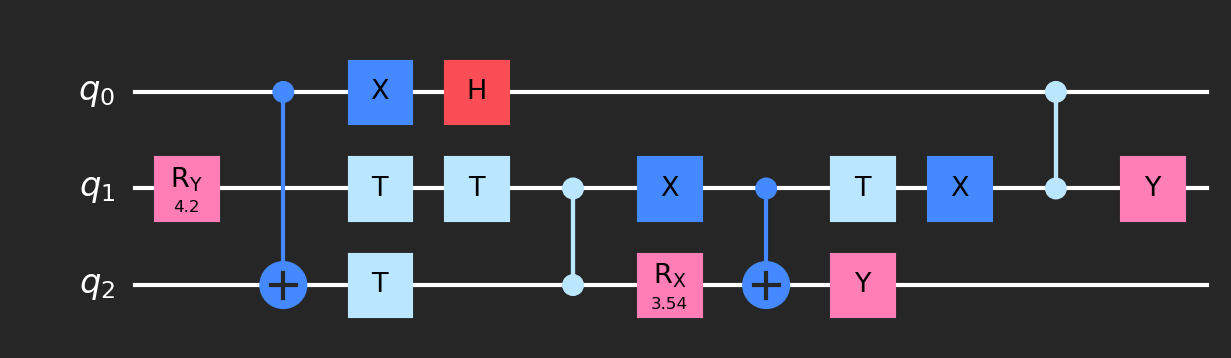

In [43]:
qc = qc_generator_final(3, 10)

qc.draw()

In [46]:
info, circuits = folding(qc)

print(info)

[{'folding_type': 'circuit', 'lambda_requested': 1.0, 'lambda_real': 1.0, 'd': 10, 'k': 0, 'n': 0, 's': 0}, {'folding_type': 'circuit', 'lambda_requested': 1.5, 'lambda_real': 1.4, 'd': 10, 'k': 2, 'n': 0, 's': 2}, {'folding_type': 'circuit', 'lambda_requested': 2.0, 'lambda_real': 2.0, 'd': 10, 'k': 5, 'n': 0, 's': 5}, {'folding_type': 'circuit', 'lambda_requested': 2.5, 'lambda_real': 2.6, 'd': 10, 'k': 8, 'n': 0, 's': 8}, {'folding_type': 'circuit', 'lambda_requested': 3.0, 'lambda_real': 3.0, 'd': 10, 'k': 10, 'n': 1, 's': 0}]
